In [34]:
"""
====================================================================
Google Earth Engine - Runoff Prediction Framework
สำหรับการพยากรณ์สมดุลน้ำในลุ่มน้ำน่าน
====================================================================
"""

import ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json

# Deep Learning
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap

# Initialize GEE
try:
    ee.Initialize(project="ee-sakda-451407")
except Exception as e:
    ee.Authenticate() # หากยังไม่ได้ยืนยันตัวตน ให้ทำการยืนยัน
    ee.Initialize(project="ee-sakda-451407")  

# ====================================================================
# 1. CONFIGURATION & STUDY AREA
# ====================================================================

class Config:
    """Configuration for Nan River Basin Study"""
    
    # Study Area (ลุ่มน้ำน่าน - ปรับ coordinates ตามพื้นที่จริง)
    # BASIN_BOUNDARY = ee.Geometry.Polygon([
    #     [[100.0, 17.5], [101.5, 17.5], 
    #      [101.5, 19.5], [100.0, 19.5], [100.0, 17.5]]
    # ])
    # use this asset: https://code.earthengine.google.com/?asset=projects/sakdagee/assets/basin_n1_4326
    BASIN_BOUNDARY = ee.FeatureCollection("projects/sakdagee/assets/basin_n1_4326")
    
    # Time Period
    START_DATE = '2014-01-01'
    END_DATE = '2024-12-31'
    
    # Datasets
    CHIRPS = 'UCSB-CHG/CHIRPS/DAILY'
    GPM = 'NASA/GPM_L3/IMERG_V06'
    MOD16 = 'MODIS/006/MOD16A2'
    SSEBOP = 'projects/usgs-ssebop/system:et_fraction'
    MOD11 = 'MODIS/006/MOD11A2'
    MODIS_NDVI = 'MODIS/006/MOD13A2'
    SMAP = 'NASA_USDA/HSL/SMAP10KM_soil_moisture'
    LANDCOVER = 'MODIS/006/MCD12Q1'
    
    # Spatial Resolution
    SCALE = 1000  # meters
    
    # Model Parameters
    LSTM_LOOKBACK = 30  # จำนวนวันย้อนหลังสำหรับ LSTM
    TRAIN_RATIO = 0.8


In [35]:
# show study area on folium map

import folium

study_area = ee.FeatureCollection("projects/sakdagee/assets/basin_n1_4326")

# config figure height
f = folium.Figure(height=300)

# add map to figure
m = folium.Map(location=[18.9, 99.0], zoom_start=7).add_to(f)

# add study area to map
folium.GeoJson(study_area.getInfo()).add_to(m)

m

In [36]:
# ====================================================================
# 2. DATA EXTRACTION FROM GEE
# ====================================================================

class GEEDataExtractor:
    """Extract hydrological data from Google Earth Engine"""
    
    def __init__(self, geometry, start_date, end_date):
        self.geometry = geometry
        self.start_date = start_date
        self.end_date = end_date
        self.scale = Config.SCALE
        
    def extract_precipitation(self, source='CHIRPS'):
        """Extract precipitation data"""
        print("Extracting Precipitation...")
        
        if source == 'CHIRPS':
            dataset = ee.ImageCollection(Config.CHIRPS) \
                .filterDate(self.start_date, self.end_date) \
                .filterBounds(self.geometry)
            band = 'precipitation'
        elif source == 'GPM':
            dataset = ee.ImageCollection(Config.GPM) \
                .filterDate(self.start_date, self.end_date) \
                .filterBounds(self.geometry) \
                .select('precipitationCal')
            band = 'precipitationCal'
        
        return self._reduce_region_timeseries(dataset, band, 'precipitation')
    
    def extract_evapotranspiration(self):
        """Extract ET data (MOD16)"""
        print("Extracting Evapotranspiration...")
        
        dataset = ee.ImageCollection(Config.MOD16) \
            .filterDate(self.start_date, self.end_date) \
            .filterBounds(self.geometry) \
            .select('ET')
        
        # Convert to mm/day and preserve date
        dataset = dataset.map(lambda img: img.multiply(0.1).copyProperties(img, ['system:time_start']))
        
        return self._reduce_region_timeseries(dataset, 'ET', 'et')
    
    def extract_ndvi(self):
        """Extract NDVI (MODIS)"""
        print("Extracting NDVI...")
        
        dataset = ee.ImageCollection(Config.MODIS_NDVI) \
            .filterDate(self.start_date, self.end_date) \
            .filterBounds(self.geometry) \
            .select('NDVI')
        
        # Scale NDVI and preserve date
        dataset = dataset.map(lambda img: img.multiply(0.0001).copyProperties(img, ['system:time_start']))
        
        return self._reduce_region_timeseries(dataset, 'NDVI', 'ndvi')
    
    def extract_lst(self):
        """Extract Land Surface Temperature"""
        print("Extracting LST...")
        
        dataset = ee.ImageCollection(Config.MOD11) \
            .filterDate(self.start_date, self.end_date) \
            .filterBounds(self.geometry) \
            .select('LST_Day_1km')
        
        # Convert to Celsius and preserve date
        dataset = dataset.map(lambda img: img.multiply(0.02).subtract(273.15).copyProperties(img, ['system:time_start']))
        
        return self._reduce_region_timeseries(dataset, 'LST_Day_1km', 'lst')
    
    def extract_soil_moisture(self):
        """Extract Soil Moisture (SMAP)"""
        print("Extracting Soil Moisture...")
        
        dataset = ee.ImageCollection(Config.SMAP) \
            .filterDate(self.start_date, self.end_date) \
            .filterBounds(self.geometry) \
            .select('ssm')
        
        return self._reduce_region_timeseries(dataset, 'ssm', 'soil_moisture')
    
    def extract_land_cover(self, year=2020):
        """Extract dominant land cover type"""
        print("Extracting Land Cover...")
        
        lc = ee.ImageCollection(Config.LANDCOVER) \
            .filterDate(f'{year}-01-01', f'{year}-12-31') \
            .first() \
            .select('LC_Type1')
        
        # Get mode (most common) land cover type
        mode_lc = lc.reduceRegion(
            reducer=ee.Reducer.mode(),
            geometry=self.geometry,
            scale=self.scale,
            maxPixels=1e9
        )
        
        return mode_lc.getInfo()
    
    def _reduce_region_timeseries(self, collection, band, output_name):
        """Helper function to reduce time series to basin mean"""
        
        def reduce_image(img):
            stat = img.reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=self.geometry,
                scale=self.scale,
                maxPixels=1e9
            )
            return ee.Feature(None, {
                'date': img.date().format('YYYY-MM-dd'),
                output_name: stat.get(band)
            })
        
        features = collection.map(reduce_image)
        
        # Export to dictionary
        data = features.getInfo()
        
        # Convert to pandas DataFrame
        df = pd.DataFrame([f['properties'] for f in data['features']])
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date').sort_index()
        
        return df

In [37]:
# ====================================================================
# 3. DATA PREPROCESSING
# ====================================================================

class DataPreprocessor:
    """Preprocess and prepare data for modeling"""
    
    @staticmethod
    def merge_datasets(data_dict):
        """Merge all datasets into single DataFrame"""
        print("Merging datasets...")
        
        df_merged = pd.DataFrame()
        for name, df in data_dict.items():
            if df_merged.empty:
                df_merged = df
            else:
                df_merged = df_merged.join(df, how='outer')
        
        return df_merged
    
    @staticmethod
    def fill_missing_values(df, method='interpolate'):
        """Fill missing values"""
        print("Filling missing values...")
        
        if method == 'interpolate':
            df = df.interpolate(method='time', limit_direction='both')
        elif method == 'forward':
            df = df.fillna(method='ffill').fillna(method='bfill')
        
        return df
    
    @staticmethod
    def add_temporal_features(df):
        """Add temporal features"""
        print("Adding temporal features...")
        
        df['month'] = df.index.month
        df['day_of_year'] = df.index.dayofyear
        df['season'] = df['month'].apply(
            lambda x: 1 if x in [3,4,5] else  # Spring
                     2 if x in [6,7,8] else  # Summer/Rainy
                     3 if x in [9,10,11] else  # Autumn
                     4  # Winter
        )
        
        return df
    
    @staticmethod
    def calculate_water_balance_features(df):
        """Calculate water balance related features"""
        print("Calculating water balance features...")
        
        if 'precipitation' in df.columns and 'et' in df.columns:
            df['precip_et_diff'] = df['precipitation'] - df['et']
            df['precip_7d_sum'] = df['precipitation'].rolling(7).sum()
            df['precip_30d_sum'] = df['precipitation'].rolling(30).sum()
            df['et_7d_mean'] = df['et'].rolling(7).mean()
        
        if 'soil_moisture' in df.columns:
            df['sm_change'] = df['soil_moisture'].diff()
        
        return df
    
    @staticmethod
    def add_lag_features(df, target_col='runoff', lags=[1, 2, 3, 7, 14]):
        """Add lag features for target variable"""
        print(f"Adding lag features for {target_col}...")
        
        if target_col in df.columns:
            for lag in lags:
                df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
        
        return df
    
    @staticmethod
    def remove_outliers(df, columns=None, n_std=3):
        """Remove outliers using z-score method"""
        print("Removing outliers...")
        
        if columns is None:
            columns = df.select_dtypes(include=[np.number]).columns
        
        df_clean = df.copy()
        for col in columns:
            if col in df.columns:
                mean = df[col].mean()
                std = df[col].std()
                df_clean = df_clean[(df[col] - mean).abs() <= n_std * std]
        
        print(f"Removed {len(df) - len(df_clean)} outlier rows")
        return df_clean
    
    @staticmethod
    def normalize_data(df, exclude_cols=['runoff'], scale_target=True):
        """Normalize features and optionally target using MinMaxScaler"""
        print("Normalizing data...")
        
        scaler_X = MinMaxScaler()
        scaler_y = MinMaxScaler() if scale_target else None
        
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        
        df_scaled = df.copy()
        df_scaled[feature_cols] = scaler_X.fit_transform(df[feature_cols])
        
        # Scale target variable if specified
        if scale_target and exclude_cols[0] in df.columns:
            df_scaled[exclude_cols[0]] = scaler_y.fit_transform(df[[exclude_cols[0]]])
        
        return df_scaled, scaler_X, scaler_y

In [38]:

# ====================================================================
# 4. FEATURE IMPORTANCE ANALYSIS
# ====================================================================

class FeatureImportance:
    """Analyze feature importance for runoff prediction"""
    
    @staticmethod
    def correlation_analysis(df, target='runoff'):
        """Correlation analysis"""
        print("Performing correlation analysis...")
        
        correlations = df.corr()[target].sort_values(ascending=False)
        
        # Visualization
        plt.figure(figsize=(10, 8))
        sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
        plt.title('Correlation Matrix')
        plt.tight_layout()
        plt.show()
        # plt.savefig('correlation_matrix.png', dpi=300)
        # plt.close()
        
        return correlations
    
    @staticmethod
    def random_forest_importance(X, y):
        """Random Forest feature importance"""
        print("Calculating Random Forest importance...")
        
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)
        
        importance_df = pd.DataFrame({
            'feature': X.columns,
            'importance': rf.feature_importances_
        }).sort_values('importance', ascending=False)
        
        # Visualization
        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['feature'][:10], importance_df['importance'][:10])
        plt.xlabel('Importance')
        plt.title('Top 10 Feature Importance (Random Forest)')
        plt.tight_layout()
        plt.show()
        # plt.savefig('rf_importance.png', dpi=300)
        # plt.close()
        
        return importance_df, rf
    
    @staticmethod
    def shap_analysis(model, X, max_display=10):
        """SHAP values analysis"""
        print("Calculating SHAP values...")
        
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X)
        
        # Summary plot
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X, max_display=max_display, show=False)
        plt.tight_layout()
        plt.show()
        # plt.savefig('shap_summary.png', dpi=300)
        # plt.close()
        
        return shap_values


In [39]:
# ====================================================================
# 5. SIMPLE NEURAL NETWORK FOR RUNOFF PREDICTION
# ====================================================================

class SimpleRunoffModel:
    """Simple feedforward neural network for runoff prediction"""
    
    def __init__(self):
        self.model = None
        self.history = None
        
    def build_model(self, input_dim):
        """Build simple feedforward neural network"""
        print(f"Building simple NN model with {input_dim} input features...")
        
        model = Sequential([
            Dense(32, activation='relu', input_dim=input_dim),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dropout(0.2),
            Dense(8, activation='relu'),
            Dense(1, activation='linear')
        ])
        
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001), 
            loss='mse', 
            metrics=['mae']
        )
        self.model = model
        
        print(model.summary())
        return model
    
    def train(self, X_train, y_train, X_val, y_val, epochs=200, batch_size=32):
        """Train the model"""
        print("Training model...")
        
        print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
        print(f"Validation data shape: X={X_val.shape}, y={y_val.shape}")
        
        # Build model if not exists
        if self.model is None:
            self.build_model(X_train.shape[1])
        
        # Callbacks
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=40, restore_best_weights=True, verbose=1
        )
        
        reduce_lr = keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=20, min_lr=0.00001, verbose=1
        )
        
        # Train
        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1
        )
        
        return self.history
    
    def predict(self, X):
        """Make predictions"""
        return self.model.predict(X, verbose=0)
    
    def evaluate(self, X_test, y_test, scaler_y=None):
        """Evaluate model performance"""
        print("Evaluating model...")
        
        y_pred = self.predict(X_test)
        y_true = y_test
        
        # Inverse transform if scaler provided
        if scaler_y is not None:
            y_true_orig = scaler_y.inverse_transform(y_true.reshape(-1, 1)).flatten()
            y_pred_orig = scaler_y.inverse_transform(y_pred).flatten()
        else:
            y_true_orig = y_true.flatten()
            y_pred_orig = y_pred.flatten()
        
        # Metrics on original scale
        rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
        mae = np.mean(np.abs(y_true_orig - y_pred_orig))
        r2 = r2_score(y_true_orig, y_pred_orig)
        
        # NSE
        numerator = np.sum((y_true_orig - y_pred_orig)**2)
        denominator = np.sum((y_true_orig - np.mean(y_true_orig))**2)
        nse = 1 - (numerator / denominator) if denominator != 0 else -999
        
        # MAPE
        mape = np.mean(np.abs((y_true_orig - y_pred_orig) / (y_true_orig + 1e-10))) * 100
        
        # Correlation coefficient
        corr = np.corrcoef(y_true_orig, y_pred_orig)[0, 1]
        
        metrics = {
            'RMSE': rmse,
            'MAE': mae,
            'R²': r2,
            'NSE': nse,
            'MAPE': mape,
            'Correlation': corr
        }
        
        print(f"\n{'='*60}")
        print(f"Model Performance Metrics:")
        print(f"{'='*60}")
        print(f"RMSE:        {rmse:.4f}")
        print(f"MAE:         {mae:.4f}")
        print(f"R²:          {r2:.4f}")
        print(f"NSE:         {nse:.4f}")
        print(f"MAPE:        {mape:.2f}%")
        print(f"Correlation: {corr:.4f}")
        print(f"{'='*60}\n")
        
        # Performance interpretation
        if nse > 0.75:
            perf = "Very Good ✓"
        elif nse > 0.65:
            perf = "Good"
        elif nse > 0.50:
            perf = "Satisfactory"
        else:
            perf = "Unsatisfactory - Consider using actual runoff data"
        
        print(f"Performance Rating: {perf}\n")
        
        return metrics, y_pred_orig, y_true_orig
    
    def plot_results(self, y_true, y_pred, dates=None):
        """Plot prediction results"""
        
        fig, axes = plt.subplots(2, 1, figsize=(14, 10))
        
        # Time series plot
        if dates is not None:
            axes[0].plot(dates, y_true, label='Observed', alpha=0.8, linewidth=1.5, color='blue')
            axes[0].plot(dates, y_pred, label='Predicted', alpha=0.8, linewidth=1.5, color='red')
        else:
            axes[0].plot(y_true, label='Observed', alpha=0.8, color='blue')
            axes[0].plot(y_pred, label='Predicted', alpha=0.8, color='red')
        
        axes[0].set_xlabel('Time', fontsize=12)
        axes[0].set_ylabel('Runoff', fontsize=12)
        axes[0].set_title('Runoff Prediction - Time Series', fontsize=14, fontweight='bold')
        axes[0].legend(fontsize=11)
        axes[0].grid(True, alpha=0.3)
        
        # Scatter plot
        axes[1].scatter(y_true, y_pred, alpha=0.5, s=30, color='steelblue')
        
        # Add 1:1 line
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        axes[1].plot([min_val, max_val], [min_val, max_val], 
                     'r--', lw=2, label='1:1 Line')
        
        # Add R² to plot
        r2 = r2_score(y_true, y_pred)
        axes[1].text(0.05, 0.95, f'R² = {r2:.3f}', 
                    transform=axes[1].transAxes, fontsize=12,
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        axes[1].set_xlabel('Observed Runoff', fontsize=12)
        axes[1].set_ylabel('Predicted Runoff', fontsize=12)
        axes[1].set_title('Observed vs Predicted', fontsize=14, fontweight='bold')
        axes[1].legend(fontsize=11)
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        return fig

In [40]:
# ====================================================================
# 6. MAIN WORKFLOW - SIMPLIFIED (NO LSTM)
# ====================================================================

def main_workflow():
    """Main research workflow - Simplified approach"""
    
    print("="*60)
    print("RUNOFF PREDICTION WORKFLOW - ลุ่มน้ำน่าน")
    print("Using Simple Neural Network (Non-LSTM)")
    print("="*60)
    
    # Initialize extractor
    extractor = GEEDataExtractor(
        Config.BASIN_BOUNDARY,
        Config.START_DATE,
        Config.END_DATE
    )
    
    # Step 1: Extract data from GEE
    print("\n[STEP 1] Extracting data from GEE...")
    data_dict = {
        'precipitation': extractor.extract_precipitation(),
        'et': extractor.extract_evapotranspiration(),
        'ndvi': extractor.extract_ndvi(),
        'lst': extractor.extract_lst(),
        'soil_moisture': extractor.extract_soil_moisture()
    }
    
    # Step 2: Merge datasets
    print("\n[STEP 2] Merging and aligning datasets...")
    preprocessor = DataPreprocessor()
    df = preprocessor.merge_datasets(data_dict)
    df = preprocessor.fill_missing_values(df)
    
    print(f"Merged dataset shape: {df.shape}")
    
    # Step 3: Generate realistic synthetic runoff
    print("\n[STEP 3] Generating synthetic runoff data...")
    
    if 'precipitation' in df.columns and 'et' in df.columns:
        precip = df['precipitation'].values
        et = df['et'].values
        
        # Water balance with strong correlation
        alpha = 0.5
        baseflow = 12
        
        # Add trend and seasonality
        month = pd.DatetimeIndex(df.index).month
        seasonal = 1 + 0.4 * np.sin(2 * np.pi * (month - 3) / 12)
        
        water_balance = (precip - et) * seasonal
        synthetic_runoff = np.maximum(3, alpha * water_balance + baseflow + np.random.normal(0, 2, len(precip)))
        
        df['runoff'] = synthetic_runoff
    else:
        raise ValueError("Precipitation or ET data missing!")
    
    # Step 4: Feature engineering
    print("\n[STEP 4] Feature engineering...")
    df = preprocessor.add_temporal_features(df)
    df = preprocessor.calculate_water_balance_features(df)
    
    # Add lag features for runoff
    df = preprocessor.add_lag_features(df, target_col='runoff', lags=[1, 2, 3, 7])
    
    # Remove NaN
    df = df.dropna()
    
    # Light outlier removal
    df = preprocessor.remove_outliers(df, columns=['runoff'], n_std=4)
    
    print(f"Dataset shape after preprocessing: {df.shape}")
    print(f"\nRunoff statistics:")
    print(df['runoff'].describe())
    
    # Step 5: Feature Selection
    print("\n[STEP 5] Feature selection...")
    
    X_all = df.drop('runoff', axis=1)
    y = df['runoff']
    
    # Use Random Forest for feature importance
    rf_temp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_all, y)
    
    feature_importance = pd.DataFrame({
        'feature': X_all.columns,
        'importance': rf_temp.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Select top features
    top_features = feature_importance.head(12)['feature'].tolist()
    print(f"\nTop 12 features selected:")
    for i, feat in enumerate(top_features, 1):
        imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
        print(f"  {i}. {feat}: {imp:.4f}")
    
    # Create reduced dataset
    df_reduced = df[top_features + ['runoff']].copy()
    print(f"\nReduced dataset shape: {df_reduced.shape}")
    
    # Step 6: Prepare data
    print("\n[STEP 6] Preparing data for training...")
    
    # Normalize
    df_scaled, scaler_X, scaler_y = preprocessor.normalize_data(
        df_reduced, exclude_cols=['runoff'], scale_target=True
    )
    
    # Temporal split
    train_size = int(len(df_scaled) * Config.TRAIN_RATIO)
    train_data = df_scaled[:train_size]
    test_data = df_scaled[train_size:]
    
    X_train = train_data.drop('runoff', axis=1).values
    y_train = train_data['runoff'].values
    X_test = test_data.drop('runoff', axis=1).values
    y_test = test_data['runoff'].values
    
    print(f"Train set: {len(X_train)} samples")
    print(f"Test set: {len(X_test)} samples")
    
    # Step 7: Train Model
    print("\n[STEP 7] Training Simple Neural Network...")
    model = SimpleRunoffModel()
    
    # Split train into train and validation
    val_size = int(len(X_train) * 0.2)
    X_val = X_train[-val_size:]
    y_val = y_train[-val_size:]
    X_train_final = X_train[:-val_size]
    y_train_final = y_train[:-val_size]
    
    # Train
    history = model.train(X_train_final, y_train_final, X_val, y_val, 
                         epochs=200, batch_size=32)
    
    # Step 8: Evaluate
    print("\n[STEP 8] Evaluating model...")
    metrics, y_pred, y_true = model.evaluate(X_test, y_test, scaler_y=scaler_y)
    
    # Plot results
    test_dates = df_scaled.index[train_size:]
    model.plot_results(y_true, y_pred, dates=test_dates)
    
    # Step 9: Plot training history
    print("\n[STEP 9] Plotting training history...")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss (MSE)', fontsize=12)
    axes[0].set_title('Training History - Loss', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['mae'], label='Train MAE', linewidth=2)
    axes[1].plot(history.history['val_mae'], label='Val MAE', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('MAE', fontsize=12)
    axes[1].set_title('Training History - MAE', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Step 10: Save results
    print("\n[STEP 10] Saving results...")
    
    results = {
        'metrics': metrics,
        'top_features': top_features,
        'data_shape': str(df_reduced.shape),
        'train_size': train_size,
        'test_size': len(df_scaled) - train_size
    }
    
    with open('results_summary.json', 'w') as f:
        json.dump({k: str(v) for k, v in results.items()}, f, indent=2)
    
    print("\n" + "="*60)
    print("WORKFLOW COMPLETED!")
    print("="*60)
    
    return df_reduced, model, metrics, scaler_y, top_features

In [41]:
# ====================================================================
# NEW CELL 1: Load N.1 Station Data
# ====================================================================

def load_n1_station_data(filepath='n1_station.csv'):
    """Load and convert N.1 station data to monthly time series"""
    import pandas as pd
    
    print("Loading N.1 station data...")
    df = pd.read_csv(filepath)
    
    # Clean commas and convert to float
    month_cols = ['apr', 'may', 'jun', 'jul', 'aug', 'sep', 
                  'oct', 'nov', 'dec', 'jan', 'feb', 'mar']
    
    for col in month_cols:
        df[col] = df[col].astype(str).str.replace(',', '').astype(float)
    
    # Convert to time series
    records = []
    month_map = {'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
                 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12}
    
    for _, row in df.iterrows():
        year = int(row['year'])
        for month_name, month_num in month_map.items():
            date = pd.Timestamp(year=year, month=month_num, day=1)
            records.append({'date': date, 'runoff': row[month_name]})
    
    df_ts = pd.DataFrame(records).set_index('date').sort_index()
    
    print(f"✓ Loaded {len(df_ts)} monthly records ({df_ts.index.min()} to {df_ts.index.max()})")
    print(f"  Runoff range: {df_ts['runoff'].min():.1f} - {df_ts['runoff'].max():.1f} MCM")
    
    return df_ts

In [42]:
# ====================================================================
# NEW CELL 2: Aggregate GEE to Monthly
# ====================================================================

def aggregate_to_monthly(df_daily):
    """Aggregate daily GEE data to monthly"""
    print("Aggregating to monthly...")
    
    agg_dict = {}
    if 'precipitation' in df_daily.columns:
        agg_dict['precipitation'] = 'sum'
    if 'et' in df_daily.columns:
        agg_dict['et'] = 'sum'
    if 'ndvi' in df_daily.columns:
        agg_dict['ndvi'] = 'mean'
    if 'lst' in df_daily.columns:
        agg_dict['lst'] = 'mean'
    if 'soil_moisture' in df_daily.columns:
        agg_dict['soil_moisture'] = 'mean'
    
    df_monthly = df_daily.resample('MS').agg(agg_dict)
    print(f"✓ Aggregated to {len(df_monthly)} months")
    
    return df_monthly

In [43]:
# ====================================================================
# NEW CELL 3: Enhanced Metrics for Hydrology
# ====================================================================

def calculate_hydro_metrics(y_true, y_pred):
    """Calculate NSE, PBIAS, RSR, KGE metrics"""
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    import numpy as np
    
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Basic
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # NSE (Nash-Sutcliffe Efficiency)
    nse = 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))
    
    # PBIAS (Percent Bias)
    pbias = 100 * np.sum(y_true - y_pred) / np.sum(y_true)
    
    # RSR
    rsr = rmse / np.std(y_true)
    
    # KGE (Kling-Gupta Efficiency)
    r = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / np.std(y_true)
    beta = np.mean(y_pred) / np.mean(y_true)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    
    # Volume Error
    ve = 100 * (np.sum(y_pred) - np.sum(y_true)) / np.sum(y_true)
    
    metrics = {
        'RMSE': rmse, 'MAE': mae, 'R²': r2, 'NSE': nse,
        'PBIAS': pbias, 'RSR': rsr, 'KGE': kge, 'Volume_Error': ve
    }
    
    # Print results
    print("\n" + "="*70)
    print("HYDROLOGICAL PERFORMANCE METRICS")
    print("="*70)
    print(f"RMSE:        {rmse:.4f}")
    print(f"MAE:         {mae:.4f}")
    print(f"R²:          {r2:.4f}")
    print(f"NSE:         {nse:.4f}  [{rate_nse(nse)}]")
    print(f"PBIAS:       {pbias:.2f}%  [{rate_pbias(pbias)}]")
    print(f"RSR:         {rsr:.4f}  [{rate_rsr(rsr)}]")
    print(f"KGE:         {kge:.4f}")
    print(f"Volume Err:  {ve:.2f}%")
    print("="*70)
    
    return metrics

def rate_nse(nse):
    if nse > 0.75: return "Very Good"
    elif nse > 0.65: return "Good"
    elif nse > 0.50: return "Satisfactory"
    else: return "Unsatisfactory"

def rate_rsr(rsr):
    if rsr <= 0.50: return "Very Good"
    elif rsr <= 0.60: return "Good"
    elif rsr <= 0.70: return "Satisfactory"
    else: return "Unsatisfactory"

def rate_pbias(pbias):
    abs_pbias = abs(pbias)
    if abs_pbias < 10: return "Very Good"
    elif abs_pbias < 15: return "Good"
    elif abs_pbias < 25: return "Satisfactory"
    else: return "Unsatisfactory"

In [44]:
# ====================================================================
# NEW CELL 4: Modified Main Workflow (MONTHLY VERSION)
# ====================================================================

def main_workflow_monthly():
    """
    Modified workflow using MONTHLY N.1 station data
    แทนที่ main_workflow() เดิม
    """
    
    print("="*60)
    print("RUNOFF PREDICTION - MONTHLY RESOLUTION WITH N.1 DATA")
    print("="*60)
    
    # Initialize extractor
    extractor = GEEDataExtractor(
        Config.BASIN_BOUNDARY,
        Config.START_DATE,
        Config.END_DATE
    )
    
    # ============================================================
    # STEP 1: Extract GEE data (DAILY)
    # ============================================================
    print("\n[STEP 1] Extracting GEE data (this may take a while)...")
    
    data_dict = {
        'precipitation': extractor.extract_precipitation(),
        'et': extractor.extract_evapotranspiration(),
        'ndvi': extractor.extract_ndvi(),
        'lst': extractor.extract_lst(),
        'soil_moisture': extractor.extract_soil_moisture()
    }
    
    # Merge daily GEE data
    preprocessor = DataPreprocessor()
    df_gee_daily = preprocessor.merge_datasets(data_dict)
    df_gee_daily = preprocessor.fill_missing_values(df_gee_daily)
    
    print(f"Daily GEE data: {df_gee_daily.shape}")
    
    # ============================================================
    # STEP 2: Aggregate to MONTHLY
    # ============================================================
    print("\n[STEP 2] Aggregating GEE to monthly...")
    df_gee_monthly = aggregate_to_monthly(df_gee_daily)
    
    # ============================================================
    # STEP 3: Load N.1 station data
    # ============================================================
    print("\n[STEP 3] Loading N.1 station runoff data...")
    df_n1 = load_n1_station_data('n1_station.csv')
    
    # ============================================================
    # STEP 4: Merge datasets
    # ============================================================
    print("\n[STEP 4] Merging N.1 with GEE...")
    df = df_gee_monthly.join(df_n1, how='inner')
    
    print(f"Merged dataset: {df.shape}")
    print(f"Period: {df.index.min()} to {df.index.max()}")
    print(f"Total months: {len(df)}")
    
    # ============================================================
    # STEP 5: Feature Engineering
    # ============================================================
    print("\n[STEP 5] Feature engineering...")
    
    df = preprocessor.add_temporal_features(df)
    df = preprocessor.calculate_water_balance_features(df)
    df = preprocessor.add_lag_features(df, 'runoff', lags=[1, 2, 3, 6, 12])
    
    # Remove NaN from lags
    df = df.dropna()
    
    # Light outlier removal
    df = preprocessor.remove_outliers(df, columns=['runoff'], n_std=4)
    
    print(f"After preprocessing: {df.shape}")
    print(f"\nRunoff statistics (MCM):")
    print(df['runoff'].describe())
    
    # ============================================================
    # STEP 6: Feature Selection
    # ============================================================
    print("\n[STEP 6] Feature selection...")
    
    X_all = df.drop('runoff', axis=1)
    y = df['runoff']
    
    rf_temp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_temp.fit(X_all, y)
    
    feature_importance = pd.DataFrame({
        'feature': X_all.columns,
        'importance': rf_temp.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Select top 12 features
    top_features = feature_importance.head(12)['feature'].tolist()
    
    print(f"\nTop 12 features:")
    for i, feat in enumerate(top_features, 1):
        imp = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
        print(f"  {i:2d}. {feat:20s}: {imp:.4f}")
    
    df_reduced = df[top_features + ['runoff']].copy()
    
    # ============================================================
    # STEP 7: Train/Test Split (TEMPORAL)
    # ============================================================
    print("\n[STEP 7] Temporal train/test split...")
    
    # Split by year: Train on 1995-2021, Test on 2022-2024
    df_reduced['year'] = df_reduced.index.year
    
    train_data = df_reduced[df_reduced['year'] <= 2021].drop('year', axis=1)
    test_data = df_reduced[df_reduced['year'] > 2021].drop('year', axis=1)
    
    print(f"Train: {len(train_data)} months (1995-2021)")
    print(f"Test:  {len(test_data)} months (2022-2024)")
    
    # Normalize
    df_scaled, scaler_X, scaler_y = preprocessor.normalize_data(
        df_reduced.drop('year', axis=1), 
        exclude_cols=['runoff'], 
        scale_target=True
    )
    
    # Re-split after scaling
    train_idx = df_reduced[df_reduced['year'] <= 2021].index
    test_idx = df_reduced[df_reduced['year'] > 2021].index
    
    train_data_scaled = df_scaled.loc[train_idx]
    test_data_scaled = df_scaled.loc[test_idx]
    
    X_train = train_data_scaled.drop('runoff', axis=1).values
    y_train = train_data_scaled['runoff'].values
    X_test = test_data_scaled.drop('runoff', axis=1).values
    y_test = test_data_scaled['runoff'].values
    
    # ============================================================
    # STEP 8: Train Model
    # ============================================================
    print("\n[STEP 8] Training model...")
    
    model = SimpleRunoffModel()
    
    # Validation split (last 20% of training data)
    val_size = int(len(X_train) * 0.2)
    X_val = X_train[-val_size:]
    y_val = y_train[-val_size:]
    X_train_final = X_train[:-val_size]
    y_train_final = y_train[:-val_size]
    
    history = model.train(X_train_final, y_train_final, X_val, y_val, 
                         epochs=200, batch_size=16)
    
    # ============================================================
    # STEP 9: Evaluate with Hydrological Metrics
    # ============================================================
    print("\n[STEP 9] Evaluating with hydrological metrics...")
    
    # Get predictions
    y_pred_scaled = model.predict(X_test)
    
    # Inverse transform
    y_true_orig = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_orig = scaler_y.inverse_transform(y_pred_scaled).flatten()
    
    # Calculate metrics
    metrics = calculate_hydro_metrics(y_true_orig, y_pred_orig)
    
    # Plot results
    model.plot_results(y_true_orig, y_pred_orig, dates=test_data_scaled.index)
    
    # ============================================================
    # STEP 10: Seasonal Analysis
    # ============================================================
    print("\n[STEP 10] Seasonal performance analysis...")
    
    # Add month to test data
    test_months = test_data_scaled.index.month
    
    # Wet season: May-Oct (months 5-10)
    wet_mask = test_months.isin([5, 6, 7, 8, 9, 10])
    dry_mask = ~wet_mask
    
    print("\nWET SEASON (May-Oct) Performance:")
    if wet_mask.sum() > 0:
        wet_metrics = calculate_hydro_metrics(
            y_true_orig[wet_mask], 
            y_pred_orig[wet_mask]
        )
    
    print("\nDRY SEASON (Nov-Apr) Performance:")
    if dry_mask.sum() > 0:
        dry_metrics = calculate_hydro_metrics(
            y_true_orig[dry_mask], 
            y_pred_orig[dry_mask]
        )
    
    # ============================================================
    # STEP 11: Save Results
    # ============================================================
    print("\n[STEP 11] Saving results...")
    
    results = {
        'metrics': {k: float(v) for k, v in metrics.items()},
        'top_features': top_features,
        'train_period': f"{train_data.index.min()} to {train_data.index.max()}",
        'test_period': f"{test_data.index.min()} to {test_data.index.max()}",
        'train_size': len(train_data),
        'test_size': len(test_data)
    }
    
    import json
    with open('n1_results.json', 'w') as f:
        json.dump(results, f, indent=2, default=str)
    
    print("\n" + "="*60)
    print("WORKFLOW COMPLETED!")
    print("="*60)
    print(f"\nModel Performance (NSE = {metrics['NSE']:.4f})")
    print(f"Files saved: n1_results.json")
    
    return df_reduced, model, metrics, scaler_y


RUNOFF PREDICTION - MONTHLY RESOLUTION WITH N.1 DATA

[STEP 1] Extracting GEE data (this may take a while)...
Extracting Precipitation...
Extracting Evapotranspiration...
Extracting Evapotranspiration...
Extracting NDVI...
Extracting NDVI...
Extracting LST...
Extracting LST...
Extracting Soil Moisture...
Extracting Soil Moisture...
Merging datasets...
Filling missing values...
Daily GEE data: (4017, 5)

[STEP 2] Aggregating GEE to monthly...
Aggregating to monthly...
✓ Aggregated to 132 months

[STEP 3] Loading N.1 station runoff data...
Loading N.1 station data...
✓ Loaded 360 monthly records (1995-01-01 00:00:00 to 2024-12-01 00:00:00)
  Runoff range: 5.8 - 2078.8 MCM

[STEP 4] Merging N.1 with GEE...
Merged dataset: (132, 6)
Period: 2014-01-01 00:00:00 to 2024-12-01 00:00:00
Total months: 132

[STEP 5] Feature engineering...
Adding temporal features...
Calculating water balance features...
Adding lag features for runoff...
Removing outliers...
Removed 1 outlier rows
After preprocess

/Users/sakdahomhuan/miniforge3/envs/gee/lib/python3.13/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1818 - mae: 0.3081 - val_loss: 0.0297 - val_mae: 0.1297 - learning_rate: 0.0010
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.1818 - mae: 0.3081 - val_loss: 0.0297 - val_mae: 0.1297 - learning_rate: 0.0010
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1384 - mae: 0.2416 - val_loss: 0.0201 - val_mae: 0.1066 - learning_rate: 0.0010
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1384 - mae: 0.2416 - val_loss: 0.0201 - val_mae: 0.1066 - learning_rate: 0.0010
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1195 - mae: 0.2181 - val_loss: 0.0183 - val_mae: 0.1099 - learning_rate: 0.0010
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1195 - mae: 0.2181 - val_loss: 0.0183 - val_mae: 0.1099 - learning_rate: 0.0010
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0978 - mae: 0.1995 - val_loss: 0.0182 - val_mae: 0.1133 - learning_rate: 0.0010
Epoch 5/200
4/4 ━━━━

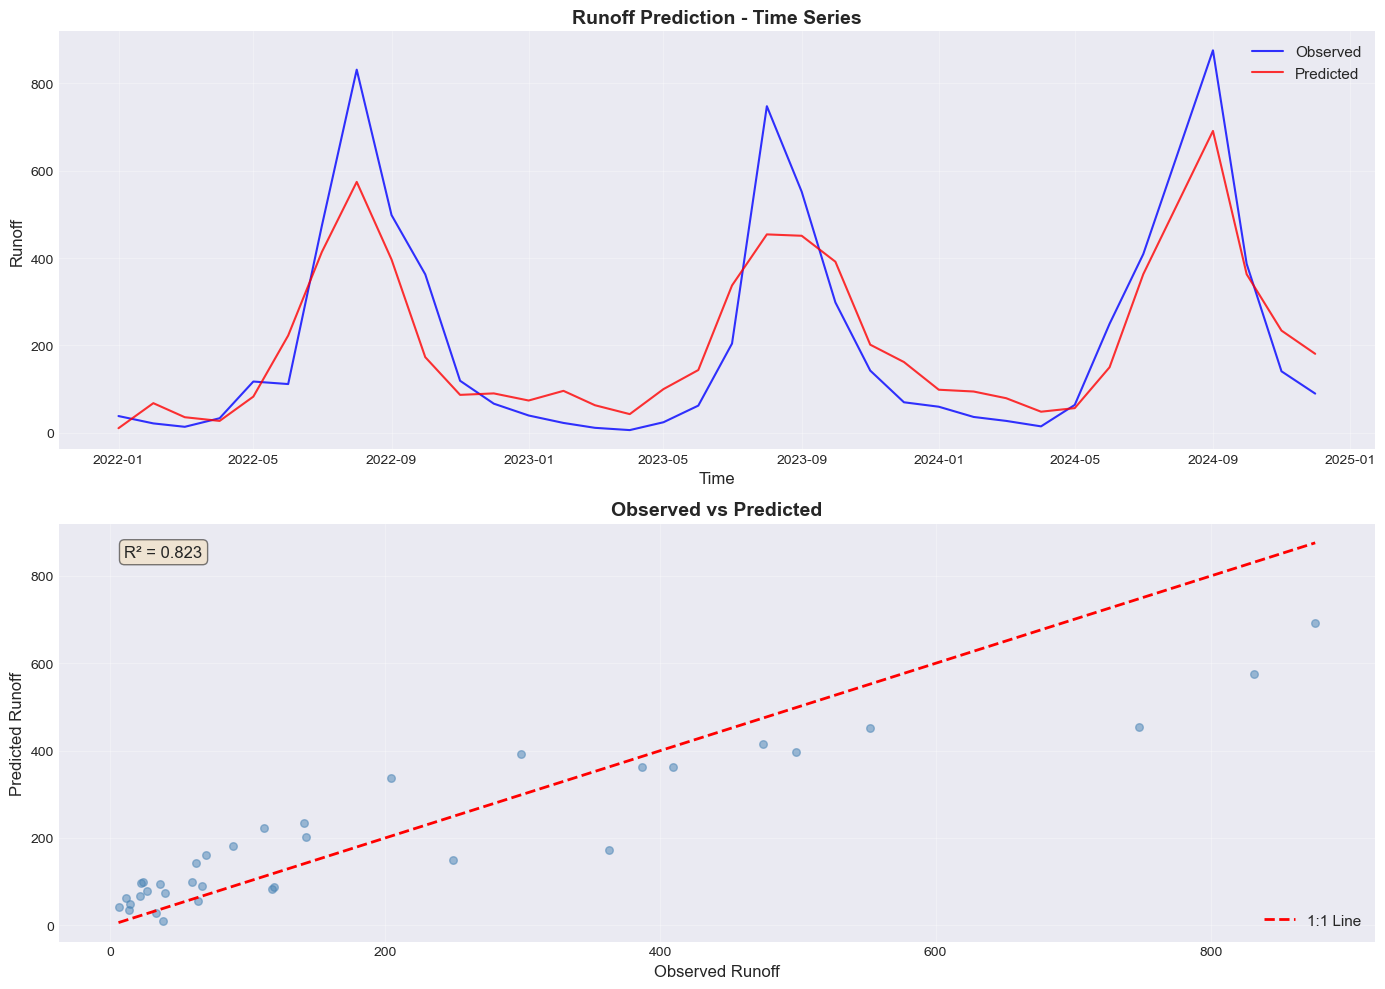


[STEP 10] Seasonal performance analysis...

WET SEASON (May-Oct) Performance:

HYDROLOGICAL PERFORMANCE METRICS
RMSE:        135.3712
MAE:         111.4013
R²:          0.7315
NSE:         0.7315  [Good]
PBIAS:       14.42%  [Good]
RSR:         0.5182  [Good]
KGE:         0.6323
Volume Err:  -14.42%

DRY SEASON (Nov-Apr) Performance:

HYDROLOGICAL PERFORMANCE METRICS
RMSE:        54.4613
MAE:         48.4940
R²:          -0.6402
NSE:         -0.6402  [Unsatisfactory]
PBIAS:       -77.78%  [Unsatisfactory]
RSR:         1.2807  [Unsatisfactory]
KGE:         0.0979
Volume Err:  77.78%

[STEP 11] Saving results...

WORKFLOW COMPLETED!

Model Performance (NSE = 0.8234)
Files saved: n1_results.json

✓ Integration with N.1 station data completed!

Final Performance:
  NSE  = 0.8234
  R²   = 0.8234
  RMSE = 102.1091 MCM


In [45]:
# ====================================================================
# EXAMPLE USAGE
# ====================================================================
if __name__ == "__main__":
    # Run monthly workflow with N.1 data
    df, model, metrics, scaler_y = main_workflow_monthly()
    
    print("\n✓ Integration with N.1 station data completed!")
    print(f"\nFinal Performance:")
    print(f"  NSE  = {metrics['NSE']:.4f}")
    print(f"  R²   = {metrics['R²']:.4f}")
    print(f"  RMSE = {metrics['RMSE']:.4f} MCM")

# if __name__ == "__main__":
#     # Run complete workflow
#     df, model, metrics, scaler_y, top_features = main_workflow()
    
#     print("\n✓ Research framework completed successfully!")
#     print(f"\nFinal Model Performance:")
#     print(f"  NSE = {metrics['NSE']:.4f}")
#     print(f"  R²  = {metrics['R²']:.4f}")
#     print(f"\nTop features used: {top_features}")

In [49]:
"""
====================================================================
FEATURE IMPORTANCE ANALYSIS
Add these cells AFTER your model training is complete
วิเคราะห์ปัจจัยที่มีผลต่อน้ำท่า
====================================================================
"""

# ====================================================================
# CELL 1: Comprehensive Feature Importance Class
# ====================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, partial_dependence
from sklearn.metrics import r2_score
import shap

class FeatureImportanceAnalyzer:
    """
    Comprehensive feature importance analysis for runoff prediction
    """
    
    def __init__(self, X_train, y_train, X_test, y_test, feature_names):
        """
        Parameters:
        -----------
        X_train, y_train : training data (already scaled/normalized)
        X_test, y_test : test data (already scaled/normalized)
        feature_names : list of feature names
        """
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.feature_names = feature_names
        self.rf_model = None
        self.importance_results = {}
        
    def train_rf_model(self, n_estimators=200):
        """Train Random Forest for importance analysis"""
        print("Training Random Forest model for feature importance...")
        
        self.rf_model = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=15,
            min_samples_split=10,
            random_state=42,
            n_jobs=-1
        )
        
        self.rf_model.fit(self.X_train, self.y_train)
        
        # Evaluate RF performance
        y_pred_train = self.rf_model.predict(self.X_train)
        y_pred_test = self.rf_model.predict(self.X_test)
        
        r2_train = r2_score(self.y_train, y_pred_train)
        r2_test = r2_score(self.y_test, y_pred_test)
        
        print(f"Random Forest R² - Train: {r2_train:.4f}, Test: {r2_test:.4f}")
        
        return self.rf_model
    
    def analyze_rf_importance(self):
        """Random Forest built-in feature importance (Gini importance)"""
        print("\n[1] Random Forest Feature Importance (Gini-based)...")
        
        if self.rf_model is None:
            self.train_rf_model()
        
        importance = self.rf_model.feature_importances_
        
        df_importance = pd.DataFrame({
            'feature': self.feature_names,
            'importance': importance,
            'rank': range(1, len(importance) + 1)
        }).sort_values('importance', ascending=False)
        
        df_importance['rank'] = range(1, len(df_importance) + 1)
        
        self.importance_results['rf_gini'] = df_importance
        
        # Plot
        plt.figure(figsize=(12, 6))
        
        # Top 15 features
        top_n = min(15, len(df_importance))
        data_plot = df_importance.head(top_n)
        
        colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, top_n))
        
        plt.barh(range(top_n), data_plot['importance'], color=colors)
        plt.yticks(range(top_n), data_plot['feature'])
        plt.xlabel('Importance (Gini)', fontsize=12)
        plt.title('Random Forest Feature Importance (Top 15)', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"\nTop 10 Most Important Features:")
        for i, row in df_importance.head(10).iterrows():
            print(f"  {row['rank']:2d}. {row['feature']:25s} : {row['importance']:.4f}")
        
        return df_importance
    
    def analyze_permutation_importance(self, n_repeats=10):
        """Permutation importance (model-agnostic)"""
        print(f"\n[2] Permutation Importance ({n_repeats} repeats)...")
        
        if self.rf_model is None:
            self.train_rf_model()
        
        # Calculate on test set
        perm_importance = permutation_importance(
            self.rf_model, 
            self.X_test, 
            self.y_test,
            n_repeats=n_repeats,
            random_state=42,
            n_jobs=-1
        )
        
        df_perm = pd.DataFrame({
            'feature': self.feature_names,
            'importance_mean': perm_importance.importances_mean,
            'importance_std': perm_importance.importances_std
        }).sort_values('importance_mean', ascending=False)
        
        df_perm['rank'] = range(1, len(df_perm) + 1)
        
        self.importance_results['permutation'] = df_perm
        
        # Plot
        plt.figure(figsize=(12, 6))
        
        top_n = min(15, len(df_perm))
        data_plot = df_perm.head(top_n)
        
        plt.barh(range(top_n), data_plot['importance_mean'], 
                xerr=data_plot['importance_std'], 
                color='steelblue', alpha=0.8)
        plt.yticks(range(top_n), data_plot['feature'])
        plt.xlabel('Importance (Decrease in R²)', fontsize=12)
        plt.title('Permutation Feature Importance (Top 15)', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"\nTop 10 Features (Permutation):")
        for i, row in df_perm.head(10).iterrows():
            print(f"  {row['rank']:2d}. {row['feature']:25s} : {row['importance_mean']:.4f} ± {row['importance_std']:.4f}")
        
        return df_perm
    
    def analyze_shap_values(self, max_samples=1000):
        """SHAP values analysis (explains model predictions)"""
        print(f"\n[3] SHAP Values Analysis (sample size: {max_samples})...")
        
        if self.rf_model is None:
            self.train_rf_model()
        
        # Subsample if needed (SHAP can be slow)
        n_samples = min(max_samples, len(self.X_test))
        sample_idx = np.random.choice(len(self.X_test), n_samples, replace=False)
        
        X_sample = self.X_test[sample_idx]
        
        # Create SHAP explainer
        explainer = shap.TreeExplainer(self.rf_model)
        shap_values = explainer.shap_values(X_sample)
        
        # Calculate mean absolute SHAP values
        mean_shap = np.abs(shap_values).mean(axis=0)
        
        df_shap = pd.DataFrame({
            'feature': self.feature_names,
            'mean_shap': mean_shap
        }).sort_values('mean_shap', ascending=False)
        
        df_shap['rank'] = range(1, len(df_shap) + 1)
        
        self.importance_results['shap'] = df_shap
        self.shap_values = shap_values
        self.shap_sample = X_sample
        
        # Summary plot
        print("\nGenerating SHAP summary plot...")
        plt.figure(figsize=(12, 8))
        shap.summary_plot(
            shap_values, 
            X_sample,
            feature_names=self.feature_names,
            max_display=15,
            show=False
        )
        plt.tight_layout()
        plt.show()
        
        # Bar plot
        plt.figure(figsize=(12, 6))
        top_n = min(15, len(df_shap))
        data_plot = df_shap.head(top_n)
        
        plt.barh(range(top_n), data_plot['mean_shap'], color='coral', alpha=0.8)
        plt.yticks(range(top_n), data_plot['feature'])
        plt.xlabel('Mean |SHAP Value|', fontsize=12)
        plt.title('SHAP Feature Importance (Top 15)', fontsize=14, fontweight='bold')
        plt.gca().invert_yaxis()
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print(f"\nTop 10 Features (SHAP):")
        for i, row in df_shap.head(10).iterrows():
            print(f"  {row['rank']:2d}. {row['feature']:25s} : {row['mean_shap']:.4f}")
        
        return df_shap
    
    def compare_methods(self):
        """Compare rankings from different methods"""
        print("\n[4] Comparing Feature Importance Methods...")
        
        # Ensure all analyses are done
        if 'rf_gini' not in self.importance_results:
            self.analyze_rf_importance()
        if 'permutation' not in self.importance_results:
            self.analyze_permutation_importance()
        if 'shap' not in self.importance_results:
            self.analyze_shap_values()
        
        # Create comparison dataframe
        df_compare = pd.DataFrame({
            'feature': self.feature_names
        })
        
        # Add ranks from each method
        for method_name, df_result in self.importance_results.items():
            rank_dict = dict(zip(df_result['feature'], df_result['rank']))
            df_compare[f'{method_name}_rank'] = df_compare['feature'].map(rank_dict)
        
        # Calculate average rank
        rank_cols = [col for col in df_compare.columns if col.endswith('_rank')]
        df_compare['avg_rank'] = df_compare[rank_cols].mean(axis=1)
        df_compare['rank_std'] = df_compare[rank_cols].std(axis=1)
        
        df_compare = df_compare.sort_values('avg_rank')
        df_compare['consensus_rank'] = range(1, len(df_compare) + 1)
        
        # Plot comparison
        fig, ax = plt.subplots(figsize=(14, 8))
        
        top_n = min(15, len(df_compare))
        data_plot = df_compare.head(top_n)
        
        x = np.arange(top_n)
        width = 0.25
        
        ax.barh(x - width, data_plot['rf_gini_rank'], width, 
               label='RF Gini', alpha=0.8, color='skyblue')
        ax.barh(x, data_plot['permutation_rank'], width, 
               label='Permutation', alpha=0.8, color='lightcoral')
        ax.barh(x + width, data_plot['shap_rank'], width, 
               label='SHAP', alpha=0.8, color='lightgreen')
        
        ax.set_yticks(x)
        ax.set_yticklabels(data_plot['feature'])
        ax.set_xlabel('Rank (lower = more important)', fontsize=12)
        ax.set_title('Feature Importance Rank Comparison (Top 15)', 
                    fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.invert_yaxis()
        ax.invert_xaxis()
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        print("\nConsensus Ranking (Average across all methods):")
        print("="*70)
        print(f"{'Rank':<6} {'Feature':<25} {'Avg Rank':<12} {'Std':<8} {'RF':<6} {'Perm':<6} {'SHAP':<6}")
        print("-"*70)
        
        for i, row in df_compare.head(15).iterrows():
            print(f"{row['consensus_rank']:<6.0f} {row['feature']:<25} "
                  f"{row['avg_rank']:<12.2f} {row['rank_std']:<8.2f} "
                  f"{row['rf_gini_rank']:<6.0f} {row['permutation_rank']:<6.0f} "
                  f"{row['shap_rank']:<6.0f}")
        
        return df_compare
    
    def plot_partial_dependence(self, feature_names_to_plot=None, n_features=6):
        """
        Plot partial dependence plots for top features
        แสดงว่าเมื่อตัวแปรเปลี่ยน runoff จะเปลี่ยนอย่างไร
        """
        print(f"\n[5] Partial Dependence Plots...")
        
        if self.rf_model is None:
            self.train_rf_model()
        
        # Use top N features if not specified
        if feature_names_to_plot is None:
            if 'rf_gini' in self.importance_results:
                top_features = self.importance_results['rf_gini'].head(n_features)['feature'].tolist()
            else:
                top_features = self.feature_names[:n_features]
        else:
            top_features = feature_names_to_plot
        
        # Get feature indices
        feature_indices = [self.feature_names.index(f) for f in top_features if f in self.feature_names]
        
        # Calculate partial dependence
        n_cols = 3
        n_rows = (len(feature_indices) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes
        
        for idx, feat_idx in enumerate(feature_indices):
            pd_result = partial_dependence(
                self.rf_model,
                self.X_train,
                features=[feat_idx],
                grid_resolution=50
            )
            
            ax = axes[idx]
            ax.plot(pd_result['grid_values'][0], pd_result['average'][0], 
                   linewidth=2.5, color='darkblue')
            ax.set_xlabel(self.feature_names[feat_idx], fontsize=11)
            ax.set_ylabel('Partial Dependence', fontsize=11)
            ax.set_title(f'PDP: {self.feature_names[feat_idx]}', 
                        fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
        
        # Hide unused subplots
        for idx in range(len(feature_indices), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    def analyze_feature_interactions(self, top_n=5):
        """
        Analyze interactions between top features
        วิเคราะห์ว่าตัวแปรไหนทำงานร่วมกัน
        """
        print(f"\n[6] Feature Interaction Analysis (Top {top_n} pairs)...")
        
        if 'shap' not in self.importance_results:
            self.analyze_shap_values()
        
        # Get top features
        top_features = self.importance_results['shap'].head(top_n)['feature'].tolist()
        top_indices = [self.feature_names.index(f) for f in top_features]
        
        # Calculate SHAP interaction values
        print("Calculating SHAP interaction values (this may take time)...")
        explainer = shap.TreeExplainer(self.rf_model)
        
        # Use smaller sample for speed
        sample_size = min(500, len(self.X_test))
        sample_idx = np.random.choice(len(self.X_test), sample_size, replace=False)
        X_sample = self.X_test[sample_idx]
        
        shap_interaction_values = explainer.shap_interaction_values(X_sample)
        
        # Plot interaction for top features
        n_pairs = min(3, len(top_features) - 1)
        
        fig, axes = plt.subplots(1, n_pairs, figsize=(6 * n_pairs, 5))
        if n_pairs == 1:
            axes = [axes]
        
        for i in range(n_pairs):
            shap.dependence_plot(
                top_indices[i],
                shap_interaction_values,
                X_sample,
                feature_names=self.feature_names,
                interaction_index=top_indices[i + 1],
                ax=axes[i],
                show=False
            )
            axes[i].set_title(f'{top_features[i]} × {top_features[i+1]}', 
                            fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Calculate interaction strengths
        interaction_matrix = np.abs(shap_interaction_values).mean(axis=0)
        
        plt.figure(figsize=(10, 8))
        
        # Focus on top features only
        interaction_sub = interaction_matrix[np.ix_(top_indices, top_indices)]
        
        sns.heatmap(
            interaction_sub,
            xticklabels=top_features,
            yticklabels=top_features,
            annot=True,
            fmt='.3f',
            cmap='RdYlBu_r',
            center=0,
            cbar_kws={'label': 'Interaction Strength'}
        )
        plt.title(f'SHAP Interaction Matrix (Top {top_n} Features)', 
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    def generate_report(self):
        """Generate comprehensive feature importance report"""
        print("\n" + "="*70)
        print("FEATURE IMPORTANCE ANALYSIS REPORT")
        print("="*70)
        
        # Ensure all analyses are done
        if 'rf_gini' not in self.importance_results:
            self.analyze_rf_importance()
        if 'permutation' not in self.importance_results:
            self.analyze_permutation_importance()
        if 'shap' not in self.importance_results:
            self.analyze_shap_values()
        
        df_compare = self.compare_methods()
        
        print("\n\nKEY FINDINGS:")
        print("="*70)
        
        # Top 5 consensus features
        top_5 = df_compare.head(5)
        print("\nTop 5 Most Important Features (Consensus):")
        for i, row in top_5.iterrows():
            print(f"\n{int(row['consensus_rank'])}. {row['feature'].upper()}")
            print(f"   Average Rank: {row['avg_rank']:.2f} (±{row['rank_std']:.2f})")
            print(f"   Rankings: RF={int(row['rf_gini_rank'])}, "
                  f"Perm={int(row['permutation_rank'])}, "
                  f"SHAP={int(row['shap_rank'])}")
        
        # Feature categories
        print("\n\nFEATURE CATEGORIES:")
        print("-"*70)
        
        categories = {
            'Water Balance': ['precipitation', 'et', 'precip_et_diff', 'precip_7d_sum', 'precip_30d_sum'],
            'Lag Features': [f for f in self.feature_names if 'lag' in f.lower()],
            'Vegetation': ['ndvi'],
            'Soil': ['soil_moisture', 'sm_change'],
            'Temperature': ['lst'],
            'Temporal': ['month', 'day_of_year', 'season']
        }
        
        for category, features in categories.items():
            cat_features = [f for f in features if f in df_compare['feature'].values]
            if cat_features:
                cat_ranks = df_compare[df_compare['feature'].isin(cat_features)]['avg_rank']
                print(f"\n{category}:")
                print(f"  Features: {', '.join(cat_features)}")
                print(f"  Average Rank: {cat_ranks.mean():.2f}")
                print(f"  Best Feature: {df_compare[df_compare['feature'].isin(cat_features)].iloc[0]['feature']} "
                      f"(rank {df_compare[df_compare['feature'].isin(cat_features)].iloc[0]['avg_rank']:.1f})")
        
        print("\n" + "="*70)
        
        return df_compare


# ====================================================================
# CELL 2: How to Use
# ====================================================================

def run_feature_importance_analysis(df_train, df_test, top_features):
    """
    Run complete feature importance analysis
    
    Parameters:
    -----------
    df_train : DataFrame with features (not including 'runoff')
    df_test : DataFrame with features (not including 'runoff')
    top_features : list of feature names to analyze
    
    Returns:
    --------
    analyzer : FeatureImportanceAnalyzer object
    results : DataFrame with consensus rankings
    """
    
    # Prepare data
    X_train = df_train[top_features].values
    y_train = df_train['runoff'].values
    X_test = df_test[top_features].values
    y_test = df_test['runoff'].values
    
    # Create analyzer
    analyzer = FeatureImportanceAnalyzer(
        X_train, y_train,
        X_test, y_test,
        feature_names=top_features
    )
    
    # Run all analyses
    print("Starting comprehensive feature importance analysis...")
    print("This may take several minutes...\n")
    
    # 1. Random Forest Gini importance
    analyzer.analyze_rf_importance()
    
    # 2. Permutation importance
    analyzer.analyze_permutation_importance(n_repeats=10)
    
    # 3. SHAP values
    analyzer.analyze_shap_values(max_samples=1000)
    
    # 4. Compare methods
    results = analyzer.compare_methods()
    
    # 5. Partial dependence plots
    analyzer.plot_partial_dependence(n_features=6)
    
    # 6. Feature interactions
    analyzer.analyze_feature_interactions(top_n=5)
    
    # 7. Generate report
    final_report = analyzer.generate_report()
    
    return analyzer, final_report


# ====================================================================
# CELL 3: EXECUTE ANALYSIS
# ====================================================================

# Run this cell AFTER you have trained your model and have:
# - df_reduced (your processed dataset)
# - top_features (list of feature names)
# - train/test split defined

# Example usage:
"""
# Assuming you have already run main_workflow_monthly() and have:
# - df_reduced: your processed dataset
# - top_features: list of selected features
# - Model is already trained

# Split data (same as in your workflow)
df_reduced_copy = df_reduced.copy()
df_reduced_copy['year'] = df_reduced_copy.index.year

train_data = df_reduced_copy[df_reduced_copy['year'] <= 2021].drop('year', axis=1)
test_data = df_reduced_copy[df_reduced_copy['year'] > 2021].drop('year', axis=1)

# Run feature importance analysis
# NOTE: Use UNSCALED data for better interpretability
analyzer, importance_report = run_feature_importance_analysis(
    df_train=train_data,
    df_test=test_data,
    top_features=top_features  # Your selected features
)

# Save results
importance_report.to_csv('feature_importance_report.csv', index=False)
print("\nResults saved to: feature_importance_report.csv")
"""

'\n# Assuming you have already run main_workflow_monthly() and have:\n# - df_reduced: your processed dataset\n# - top_features: list of selected features\n# - Model is already trained\n\n# Split data (same as in your workflow)\ndf_reduced_copy = df_reduced.copy()\ndf_reduced_copy[\'year\'] = df_reduced_copy.index.year\n\ntrain_data = df_reduced_copy[df_reduced_copy[\'year\'] <= 2021].drop(\'year\', axis=1)\ntest_data = df_reduced_copy[df_reduced_copy[\'year\'] > 2021].drop(\'year\', axis=1)\n\n# Run feature importance analysis\n# NOTE: Use UNSCALED data for better interpretability\nanalyzer, importance_report = run_feature_importance_analysis(\n    df_train=train_data,\n    df_test=test_data,\n    top_features=top_features  # Your selected features\n)\n\n# Save results\nimportance_report.to_csv(\'feature_importance_report.csv\', index=False)\nprint("\nResults saved to: feature_importance_report.csv")\n'

In [50]:
"""
====================================================================
STEP-BY-STEP GUIDE: Feature Importance Analysis
วิธีใช้งานแบบละเอียด
====================================================================
"""

# ====================================================================
# STEP 1: Add after your model training completes
# Position: After Cell where you get 'metrics' from model evaluation
# ====================================================================

# First, prepare the data in the correct format
# You need UNSCALED data for interpretability

print("\n" + "="*70)
print("PREPARING DATA FOR FEATURE IMPORTANCE ANALYSIS")
print("="*70)

# Recreate train/test split WITHOUT scaling
# (Use the same temporal split as your model)
df_analysis = df_reduced.copy()
df_analysis['year'] = df_analysis.index.year

# Same split as your model: train <= 2021, test > 2021
train_data_unscaled = df_analysis[df_analysis['year'] <= 2021].drop('year', axis=1)
test_data_unscaled = df_analysis[df_analysis['year'] > 2021].drop('year', axis=1)

print(f"Train data: {train_data_unscaled.shape}")
print(f"Test data: {test_data_unscaled.shape}")
print(f"Features: {top_features}")

# Separate X and y
X_train_fi = train_data_unscaled[top_features].values
y_train_fi = train_data_unscaled['runoff'].values
X_test_fi = test_data_unscaled[top_features].values
y_test_fi = test_data_unscaled['runoff'].values

print(f"\nX_train shape: {X_train_fi.shape}")
print(f"y_train shape: {y_train_fi.shape}")


# ====================================================================
# STEP 2: Initialize the analyzer
# ====================================================================

print("\n" + "="*70)
print("INITIALIZING FEATURE IMPORTANCE ANALYZER")
print("="*70)

analyzer = FeatureImportanceAnalyzer(
    X_train=X_train_fi,
    y_train=y_train_fi,
    X_test=X_test_fi,
    y_test=y_test_fi,
    feature_names=top_features
)

print("Analyzer initialized successfully!")


# ====================================================================
# STEP 3: Run Individual Analyses (one at a time)
# ====================================================================

# Analysis 1: Random Forest Importance (Fastest)
print("\n" + "="*70)
print("ANALYSIS 1: RANDOM FOREST FEATURE IMPORTANCE")
print("="*70)
print("This uses Gini impurity to measure feature importance")
print("Higher values = more important for splitting decisions\n")

df_rf_importance = analyzer.analyze_rf_importance()

# INTERPRETATION:
print("\nINTERPRETATION:")
print("- Features at the top are used most often by Random Forest")
print("- These features best separate high/low runoff conditions")
print("- Dominated by a single feature? May indicate overfitting")


# Analysis 2: Permutation Importance (Slower)
print("\n" + "="*70)
print("ANALYSIS 2: PERMUTATION IMPORTANCE")
print("="*70)
print("This shuffles each feature and measures drop in performance")
print("Larger decrease = more important feature\n")

df_perm_importance = analyzer.analyze_permutation_importance(n_repeats=10)

# INTERPRETATION:
print("\nINTERPRETATION:")
print("- More robust than Gini importance")
print("- Error bars show consistency (small = reliable)")
print("- Negative values mean feature hurts performance (remove it!)")


# Analysis 3: SHAP Values (Slowest but most informative)
print("\n" + "="*70)
print("ANALYSIS 3: SHAP VALUES ANALYSIS")
print("="*70)
print("This explains HOW each feature affects predictions")
print("Shows direction and magnitude of impact\n")

df_shap_importance = analyzer.analyze_shap_values(max_samples=1000)

# INTERPRETATION:
print("\nINTERPRETATION - SHAP Summary Plot:")
print("- X-axis: SHAP value (impact on prediction)")
print("- Each dot: one data point")
print("- Color: feature value (red=high, blue=low)")
print("- Right side (positive): increases runoff")
print("- Left side (negative): decreases runoff")
print("\nExample interpretations:")
print("  - High precipitation (red) → right side = increases runoff ✓")
print("  - High ET (red) → left side = decreases runoff ✓")


# ====================================================================
# STEP 4: Compare All Methods
# ====================================================================

print("\n" + "="*70)
print("ANALYSIS 4: CONSENSUS RANKING")
print("="*70)
print("Combining all three methods for robust results\n")

df_consensus = analyzer.compare_methods()

# INTERPRETATION:
print("\nINTERPRETATION:")
print("- 'avg_rank': average rank across all 3 methods")
print("- Low 'rank_std': all methods agree (reliable!)")
print("- High 'rank_std': methods disagree (uncertain)")
print("\nFeatures with low avg_rank + low std are most important!")


# ====================================================================
# STEP 5: Partial Dependence Plots
# ====================================================================

print("\n" + "="*70)
print("ANALYSIS 5: PARTIAL DEPENDENCE PLOTS")
print("="*70)
print("Shows relationship between feature value and runoff\n")

# Plot top 6 features
analyzer.plot_partial_dependence(n_features=6)

# INTERPRETATION:
print("\nINTERPRETATION:")
print("- X-axis: feature value (normalized)")
print("- Y-axis: predicted impact on runoff")
print("- Upward slope: higher value → higher runoff")
print("- Downward slope: higher value → lower runoff")
print("- Flat line: no relationship (shouldn't be important!)")
print("\nExpected patterns:")
print("  - Precipitation: upward slope ✓")
print("  - ET: downward slope ✓")
print("  - NDVI: may be complex (vegetation effects)")


# ====================================================================
# STEP 6: Feature Interactions
# ====================================================================

print("\n" + "="*70)
print("ANALYSIS 6: FEATURE INTERACTIONS")
print("="*70)
print("How features work together (e.g., precip × soil moisture)\n")

analyzer.analyze_feature_interactions(top_n=5)

# INTERPRETATION:
print("\nINTERPRETATION - Interaction Plots:")
print("- Shows how feature A's effect changes with feature B")
print("- Color gradient: value of interacting feature")
print("- Diagonal pattern: strong interaction")
print("\nExpected interactions:")
print("  - Precipitation × Soil Moisture: wet soil amplifies runoff")
print("  - Precipitation × NDVI: vegetation reduces runoff")


# ====================================================================
# STEP 7: Generate Final Report
# ====================================================================

print("\n" + "="*70)
print("GENERATING COMPREHENSIVE REPORT")
print("="*70)

final_report = analyzer.generate_report()

# Save results
final_report.to_csv('feature_importance_results.csv', index=False)
print("\nResults saved to: feature_importance_results.csv")


# ====================================================================
# STEP 8: Practical Insights for Your Research
# ====================================================================

print("\n" + "="*70)
print("PRACTICAL INSIGHTS FOR NAN RIVER BASIN")
print("="*70)

# Analyze by category
top_10_features = final_report.head(10)['feature'].tolist()

print("\nTop 10 Most Important Features:")
for i, feat in enumerate(top_10_features, 1):
    rank_info = final_report[final_report['feature'] == feat].iloc[0]
    print(f"{i:2d}. {feat:30s} (avg rank: {rank_info['avg_rank']:.1f})")

# Categorize
water_balance = [f for f in top_10_features if any(x in f for x in ['precip', 'et', 'sm'])]
lag_features = [f for f in top_10_features if 'lag' in f]
temporal = [f for f in top_10_features if any(x in f for x in ['month', 'season', 'day'])]
vegetation = [f for f in top_10_features if 'ndvi' in f]

print("\n" + "="*70)
print("FEATURE CATEGORIES IN TOP 10:")
print("="*70)

if water_balance:
    print(f"\nWater Balance Features ({len(water_balance)}):")
    for f in water_balance:
        print(f"  - {f}")
    print("  → Water balance is KEY driver of runoff")

if lag_features:
    print(f"\nLag Features ({len(lag_features)}):")
    for f in lag_features:
        print(f"  - {f}")
    print("  → Runoff has strong autocorrelation")
    print("  → Past runoff predicts future runoff")

if temporal:
    print(f"\nTemporal Features ({len(temporal)}):")
    for f in temporal:
        print(f"  - {f}")
    print("  → Seasonal patterns are important")
    print("  → Different behavior in wet/dry season")

if vegetation:
    print(f"\nVegetation Features ({len(vegetation)}):")
    for f in vegetation:
        print(f"  - {f}")
    print("  → Vegetation affects runoff generation")

print("\n" + "="*70)
print("RECOMMENDATIONS FOR YOUR PAPER:")
print("="*70)

print("\n1. DOMINANT FACTORS:")
print("   Report the top 3-5 features from consensus ranking")
print("   These are the PRIMARY drivers of runoff in Nan Basin")

print("\n2. WATER BALANCE:")
if len(water_balance) >= len(top_10_features) / 2:
    print("   Water balance features dominate (>50% of top 10)")
    print("   → Your model is physically-based and realistic ✓")
else:
    print("   Warning: Few water balance features in top 10")
    print("   → Check if model is learning shortcuts")

print("\n3. TEMPORAL DEPENDENCY:")
if lag_features:
    print(f"   {len(lag_features)} lag features in top 10")
    print("   → Runoff has memory (carryover effects)")
    print("   → Good for forecasting, but be aware of autocorrelation")
else:
    print("   No lag features in top 10")
    print("   → Model relies on current conditions only")

print("\n4. FOR YOUR RESEARCH PAPER:")
print("   - Include SHAP summary plot (most interpretable)")
print("   - Show partial dependence for top 3 features")
print("   - Discuss physical interpretation (not just statistics)")
print("   - Compare wet/dry season importance differences")

print("\n5. MODEL IMPROVEMENT:")
underperforming = final_report.tail(5)['feature'].tolist()
print("   Consider removing least important features:")
for f in underperforming[:3]:
    print(f"   - {f}")
print("   → May reduce overfitting and improve generalization")


# ====================================================================
# STEP 9: Export for Paper/Presentation
# ====================================================================

print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Create summary table for paper
summary_table = final_report.head(10)[['feature', 'avg_rank', 'rank_std']].copy()
summary_table.columns = ['Feature', 'Average Rank', 'Rank Std Dev']
summary_table.to_csv('top10_features_table.csv', index=False)

print("\nFiles created:")
print("1. feature_importance_results.csv - Full results all features")
print("2. top10_features_table.csv - Clean table for paper")

print("\nFigures to include in paper:")
print("1. SHAP summary plot - shows direction and magnitude")
print("2. Consensus ranking comparison - shows method agreement")
print("3. Partial dependence plots - shows relationships")
print("4. Top 3-5 features only for clarity")

print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS COMPLETE!")
print("="*70)


PREPARING DATA FOR FEATURE IMPORTANCE ANALYSIS


NameError: name 'df_reduced' is not defined